<a href="https://colab.research.google.com/github/chikuu303/customer-churn-ml-project/blob/main/credit_default_risk_dataset_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Default Risk Dataset

This notebook creates the synthetic Credit Default Risk dataset used for the supervised classification project.

In [ ]:
import pandas as pd
import numpy as np

# Reproducible results
np.random.seed(42)

# Number of records
n = 500

# Create synthetic customer data
df = pd.DataFrame({
    "Age": np.random.randint(21, 65, n),
    "Income": np.random.randint(20000, 120000, n),
    "CreditScore": np.random.randint(300, 851, n),
    "Education": np.random.choice(
        ["High School", "Graduate", "Postgraduate"], n
    ),
    "EmploymentType": np.random.choice(
        ["Salaried", "Self-employed", "Business"], n
    ),
    "LoanAmount": np.random.randint(5000, 100000, n),
    "MaritalStatus": np.random.choice(
        ["Single", "Married"], n
    )
})

# Create a synthetic default target
risk_score = (
    (700 - df["CreditScore"]) / 100
    + (df["LoanAmount"] / 50000)
    - (df["Income"] / 100000)
    + np.random.normal(0, 0.8, n)
)

df["Default"] = (risk_score > 1.5).astype(int)

# Add a few missing values for preprocessing practice
for column in ["Income", "CreditScore", "Education"]:
    indices = np.random.choice(df.index, size=10, replace=False)
    df.loc[indices, column] = np.nan

print("Dataset created successfully!")
print("Shape:", df.shape)
df.head()


In [4]:
import pandas as pd
import numpy as np

# Set random seed
np.random.seed(42)

# Number of records
n = 500

# Create the dataset
df = pd.DataFrame({
    "Age": np.random.randint(21, 65, n),
    "Income": np.random.randint(20000, 120000, n),
    "CreditScore": np.random.randint(300, 851, n),
    "Education": np.random.choice(
        ["High School", "Graduate", "Postgraduate"], n
    ),
    "EmploymentType": np.random.choice(
        ["Salaried", "Self-employed", "Business"], n
    ),
    "LoanAmount": np.random.randint(5000, 100000, n),
    "MaritalStatus": np.random.choice(
        ["Single", "Married"], n
    )
})

# Create Default target
risk_score = (
    (700 - df["CreditScore"]) / 100
    + (df["LoanAmount"] / 50000)
    - (df["Income"] / 100000)
    + np.random.normal(0, 0.8, n)
)

df["Default"] = (risk_score > 1.5).astype(int)

# Add missing values
for column in ["Income", "CreditScore", "Education"]:
    indices = np.random.choice(df.index, size=10, replace=False)
    df.loc[indices, column] = np.nan

# Save the dataset
df.to_csv("credit_default_risk.csv", index=False)

print("Dataset created successfully!")
print("Dataset shape:", df.shape)
print("CSV file saved successfully!")

# Display first 5 rows
df.head()

Dataset created successfully!
Dataset shape: (500, 8)
CSV file saved successfully!


,Age,Income,CreditScore,Education,EmploymentType,LoanAmount,MaritalStatus,Default
0,59,40358.0,618.0,Postgraduate,Self-employed,53758,Single,0
1,49,23267.0,628.0,Graduate,Self-employed,81272,Married,1
2,35,102745.0,849.0,Postgraduate,Business,42643,Married,0
3,63,109588.0,718.0,Graduate,Business,55408,Married,0
4,28,58513.0,394.0,Postgraduate,Salaried,48950,Married,1


In [5]:
# Check the target distribution
print("Default value counts:")
print(df["Default"].value_counts())

print("\nDataset information:")
df.info()


Default value counts:
Default
1    274
0    226
Name: count, dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             500 non-null    int64  
 1   Income          490 non-null    float64
 2   CreditScore     490 non-null    float64
 3   Education       490 non-null    object 
 4   EmploymentType  500 non-null    object 
 5   LoanAmount      500 non-null    int64  
 6   MaritalStatus   500 non-null    object 
 7   Default         500 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 31.4+ KB


In [6]:
# Check the dataset

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDefault Distribution:")
print(df["Default"].value_counts())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(500, 8)

Column Names:
['Age', 'Income', 'CreditScore', 'Education', 'EmploymentType', 'LoanAmount', 'MaritalStatus', 'Default']

Missing Values:
Age                0
Income            10
CreditScore       10
Education         10
EmploymentType     0
LoanAmount         0
MaritalStatus      0
Default            0
dtype: int64

Default Distribution:
Default
1    274
0    226
Name: count, dtype: int64

First 5 Rows:


,Age,Income,CreditScore,Education,EmploymentType,LoanAmount,MaritalStatus,Default
0,59,40358.0,618.0,Postgraduate,Self-employed,53758,Single,0
1,49,23267.0,628.0,Graduate,Self-employed,81272,Married,1
2,35,102745.0,849.0,Postgraduate,Business,42643,Married,0
3,63,109588.0,718.0,Graduate,Business,55408,Married,0
4,28,58513.0,394.0,Postgraduate,Salaried,48950,Married,1


In [7]:
# Separate features (X) and target (y)

X = df.drop("Default", axis=1)
y = df["Default"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features (X):
['Age', 'Income', 'CreditScore', 'Education', 'EmploymentType', 'LoanAmount', 'MaritalStatus']

Target (y):
Default

Feature shape: (500, 7)
Target shape: (500,)


In [11]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

print("train_test_split imported successfully!")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

train_test_split imported successfully!
Training data shape: (400, 7)
Testing data shape: (100, 7)

Training target distribution:
Default
1    219
0    181
Name: count, dtype: int64

Testing target distribution:
Default
1    55
0    45
Name: count, dtype: int64


In [12]:
# Import preprocessing tools

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define numerical and categorical columns

numerical_features = [
    "Age",
    "Income",
    "CreditScore",
    "LoanAmount"
]

categorical_features = [
    "Education",
    "EmploymentType",
    "MaritalStatus"
]

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [14]:
# Test the preprocessing pipeline

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

preprocessor.fit_transform(X_train)
preprocessor.transform(X_test)

Preprocessing completed successfully!
Processed training data shape: (400, 12)
Processed testing data shape: (100, 12)


array([[ 0.99860157,  0.31877767, -0.85106504, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.44970396, -1.30657482, -0.24672741, ...,  1.        ,
         1.        ,  0.        ],
       [-0.96174701, -1.03053472, -1.41598936, ...,  1.        ,
         1.        ,  0.        ],
       ...,
       [ 0.76335974, -0.62050423, -1.28461161, ...,  1.        ,
         1.        ,  0.        ],
       [-0.17760758,  0.45543083, -1.61305598, ...,  1.        ,
         1.        ,  0.        ],
       [-0.64809124, -0.66214989, -1.56707376, ...,  0.        ,
         0.        ,  1.        ]])

In [15]:
# Import the required models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Create the four baseline models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

print("4 baseline models created successfully!")

4 baseline models created successfully!


In [16]:
# Train all four baseline models

trained_models = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    trained_models[name] = model
    print(name, "trained successfully!")

print("\nAll models trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!
XGBoost trained successfully!

All models trained successfully!


Step 12 — Evaluate the Baseline Models

We'll calculate:

Precision → How many predicted defaults were actually defaults
Recall → How many actual defaults the model detected
F1-score → Balance between precision and recall
ROC-AUC → Overall ability to distinguish default vs. non-default

In [18]:
# Evaluate all baseline models

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Evaluation metrics imported successfully!")

results = []

for name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test_processed)

    # Probability of Default = 1
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # Calculate metrics
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Display rounded values
results_df.round(4)

Evaluation metrics imported successfully!


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8833,0.9636,0.9217,0.9669
1,Decision Tree,0.8571,0.8727,0.8649,0.8475
2,Random Forest,0.8814,0.9455,0.9123,0.9404
3,XGBoost,0.8966,0.9455,0.9204,0.9515


Step 13 — ROC-AUC Curves

The ROC curve shows how well each model separates:

0 → No Default
1 → Default

We'll plot all four models on one graph.

<Figure size 900x600 with 0 Axes>

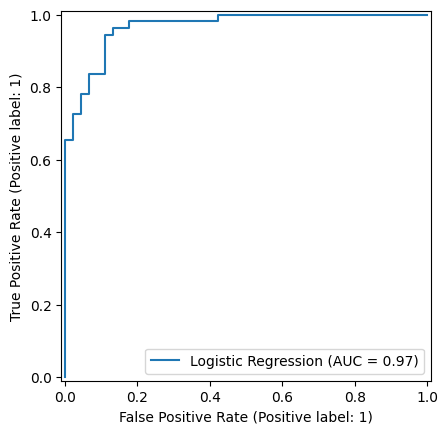

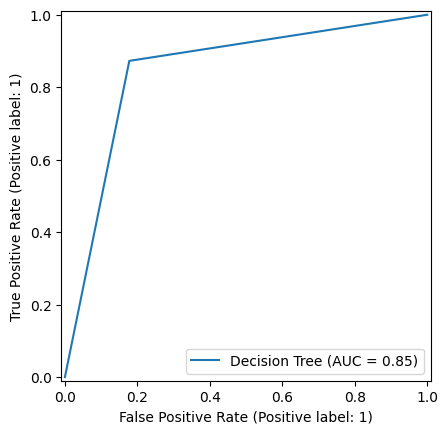

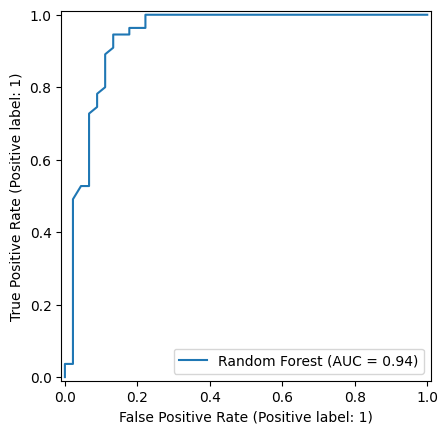

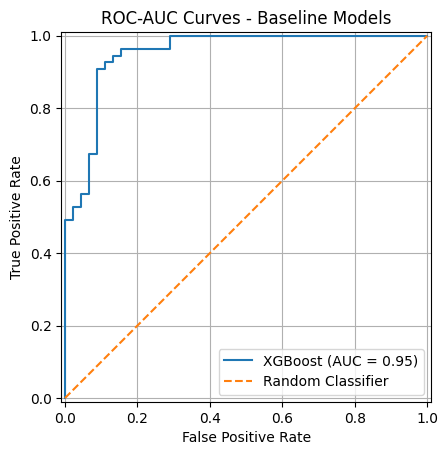

In [23]:
# Import everything needed for ROC curve

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Create ROC-AUC plot
plt.figure(figsize=(9, 6))

for name, model in trained_models.items():

    # Get probability predictions
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # Plot ROC curve
    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=name
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC-AUC Curves - Baseline Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

In [24]:
# Step 1: Hyperparameter Tuning for Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# Create a pipeline with preprocessing and Logistic Regression
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Define parameter combinations to test
logistic_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

# Use 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Run GridSearchCV
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Train and tune using the original training data
logistic_grid.fit(X_train, y_train)

print("Logistic Regression tuning completed!")
print("Best Parameters:", logistic_grid.best_params_)
print("Best Validation ROC-AUC:", round(logistic_grid.best_score_, 4))

Logistic Regression tuning completed!
Best Parameters: {'model__C': 10, 'model__solver': 'liblinear'}
Best Validation ROC-AUC: 0.9451


In [25]:
# Step 2: Hyperparameter Tuning for Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Create pipeline
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Parameters to test
decision_tree_params = {
    "model__max_depth": [None, 3, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

# GridSearchCV
decision_tree_grid = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=decision_tree_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Train and tune
decision_tree_grid.fit(X_train, y_train)

print("Decision Tree tuning completed!")
print("Best Parameters:", decision_tree_grid.best_params_)
print("Best Validation ROC-AUC:",
      round(decision_tree_grid.best_score_, 4))

Decision Tree tuning completed!
Best Parameters: {'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best Validation ROC-AUC: 0.9123


In [26]:
# Step 3: Hyperparameter Tuning for Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Create pipeline
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# Parameters to test
random_forest_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

# GridSearchCV
random_forest_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Train and tune
random_forest_grid.fit(X_train, y_train)

print("Random Forest tuning completed!")
print("Best Parameters:", random_forest_grid.best_params_)
print(
    "Best Validation ROC-AUC:",
    round(random_forest_grid.best_score_, 4)
)

Random Forest tuning completed!
Best Parameters: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best Validation ROC-AUC: 0.9338


In [27]:
# Step 4: Hyperparameter Tuning for XGBoost

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Create pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# Parameters to test
xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

# GridSearchCV
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Train and tune
xgb_grid.fit(X_train, y_train)

print("XGBoost tuning completed!")
print("Best Parameters:", xgb_grid.best_params_)
print(
    "Best Validation ROC-AUC:",
    round(xgb_grid.best_score_, 4)
)

XGBoost tuning completed!
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best Validation ROC-AUC: 0.9305


In [28]:
# Step 5: Compare all tuned models

tuned_models = {
    "Logistic Regression": logistic_grid.best_estimator_,
    "Decision Tree": decision_tree_grid.best_estimator_,
    "Random Forest": random_forest_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():

    # Predictions on test data
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    precision = precision_score(
        y_test, y_pred, zero_division=0
    )

    recall = recall_score(
        y_test, y_pred, zero_division=0
    )

    f1 = f1_score(
        y_test, y_pred, zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test, y_prob
    )

    tuned_results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Create comparison table
tuned_results_df = pd.DataFrame(tuned_results)

print("Tuned Model Comparison:")
display(tuned_results_df.round(4))

Tuned Model Comparison:


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8833,0.9636,0.9217,0.9669
1,Decision Tree,0.8793,0.9273,0.9027,0.9475
2,Random Forest,0.8413,0.9636,0.8983,0.9483
3,XGBoost,0.8548,0.9636,0.9060,0.9600


Step 6: Select the Champion Model 🏆

We'll select the model with the highest validation ROC-AUC from the GridSearchCV results. This is better than selecting it using the test set.

Create a new Colab cell and run:

In [29]:
# Step 6: Select Champion Model

best_models = {
    "Logistic Regression": logistic_grid,
    "Decision Tree": decision_tree_grid,
    "Random Forest": random_forest_grid,
    "XGBoost": xgb_grid
}

# Get validation ROC-AUC scores
validation_scores = {}

for name, grid in best_models.items():
    validation_scores[name] = grid.best_score_

# Display validation scores
print("Validation ROC-AUC Scores:")
for name, score in validation_scores.items():
    print(f"{name}: {score:.4f}")

# Select model with highest validation ROC-AUC
champion_name = max(
    validation_scores,
    key=validation_scores.get
)

champion_model = best_models[champion_name].best_estimator_

print("\n" + "=" * 50)
print("CHAMPION MODEL")
print("=" * 50)
print("Model:", champion_name)
print(
    "Validation ROC-AUC:",
    round(validation_scores[champion_name], 4)
)
print(
    "Best Parameters:",
    best_models[champion_name].best_params_
)

Validation ROC-AUC Scores:
Logistic Regression: 0.9451
Decision Tree: 0.9123
Random Forest: 0.9338
XGBoost: 0.9305

CHAMPION MODEL
Model: Logistic Regression
Validation ROC-AUC: 0.9451
Best Parameters: {'model__C': 10, 'model__solver': 'liblinear'}


Step 7: Evaluate the Champion Model

Now we'll test our selected model on the unseen test data and calculate all the required metrics.

In [30]:
# Step 7: Evaluate Champion Model

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_champion = champion_model.predict(X_test)
y_prob_champion = champion_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_champion)
precision = precision_score(y_test, y_pred_champion, zero_division=0)
recall = recall_score(y_test, y_pred_champion, zero_division=0)
f1 = f1_score(y_test, y_pred_champion, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob_champion)

print("=" * 50)
print("CHAMPION MODEL TEST PERFORMANCE")
print("=" * 50)

print("Model:", champion_name)
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_champion,
    zero_division=0
))

CHAMPION MODEL TEST PERFORMANCE
Model: Logistic Regression
Accuracy: 0.91
Precision: 0.8833
Recall: 0.9636
F1-Score: 0.9217
ROC-AUC: 0.9669

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89        45
           1       0.88      0.96      0.92        55

    accuracy                           0.91       100
   macro avg       0.92      0.90      0.91       100
weighted avg       0.91      0.91      0.91       100



Step 8: Confusion Matrix

Now let's visualize how many predictions were correct and incorrect.

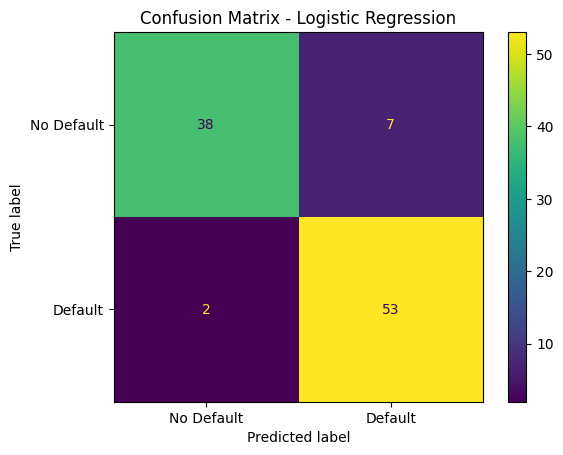

In [31]:
# Step 8: Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_champion)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
)

disp.plot()

plt.title(f"Confusion Matrix - {champion_name}")
plt.show()

Step 9: ROC-AUC Curve for Champion Model 📈

<Figure size 800x600 with 0 Axes>

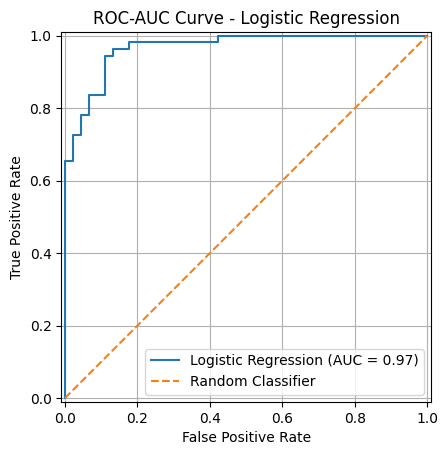

In [32]:
# Step 9: ROC-AUC Curve for Champion Model

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_champion,
    name=champion_name
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(f"ROC-AUC Curve - {champion_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

In [33]:
# Step 10: Save the Champion Model

import joblib

# Save the complete champion pipeline
joblib.dump(champion_model, "champion_model.joblib")

print("Champion model saved successfully!")
print("File name: champion_model.joblib")

Champion model saved successfully!
File name: champion_model.joblib
